In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_excel("C:\Dharan\Cheat Sheets\Datasets\Data_Train.xlsx")

In [5]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


# Univariate Analysis Workflow

We'll analyze one feature at a time.

## Step 1: Separate Numerical and Categorical Columns

In [6]:
num_cols = df.select_dtypes(include='number').columns

cat_cols = df.select_dtypes(exclude='number').columns

print(num_cols)
print(cat_cols)

Index(['Price'], dtype='object')
Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info'],
      dtype='object')


## Numerical Features

For every numerical column, answer these questions:

### 1. Basic Statistics
Look for:

- Mean
- Median (50%)
- Standard Deviation
- Min
- Max
- Quartiles

In [7]:
df[['Price']].describe()   # or else use df[['Price']].describe().to_frame()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


## 2. Distribution

Questions:
- Is it normally distributed?
- Is it skewed?
- Are there multiple peaks?

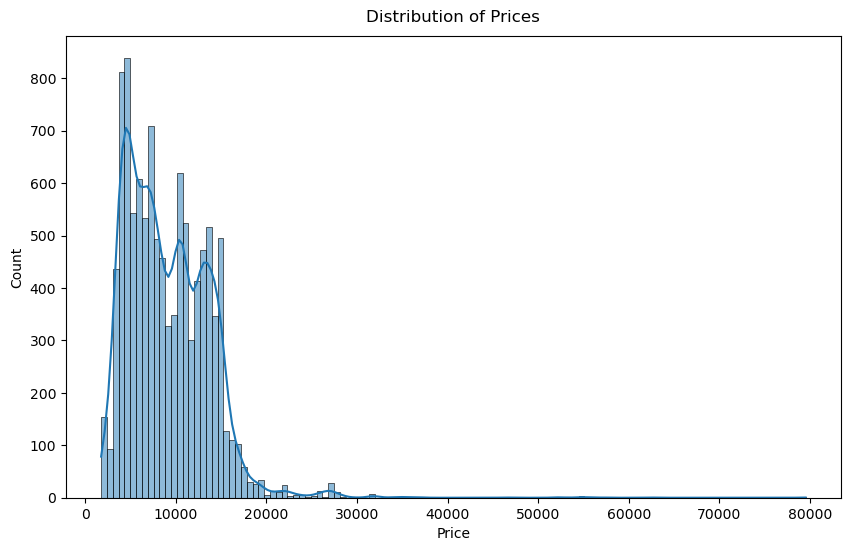

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(df['Price'], kde=True)
plt.title('Distribution of Prices', pad=10)
plt.show()

## 3. Outliers
Questions:
- Are there outliers?
- Are they extreme?

<Axes: ylabel='Price'>

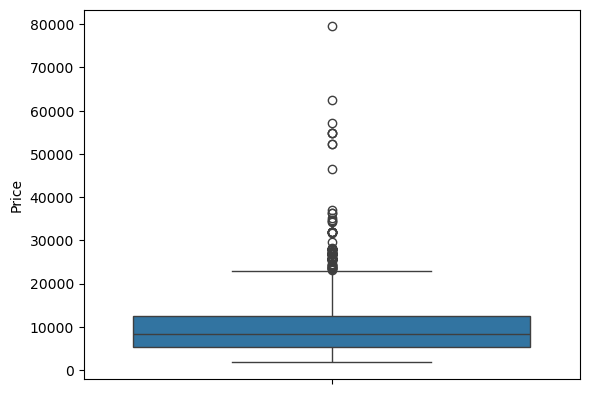

In [9]:
sns.boxplot(df.Price)

### Price
> - Prices range from ₹1,759 to ₹79,512.
> - The distribution is right-skewed.
> - Most ticket prices are below ₹20,000.
> - Several high-price outliers are present.

### Categorical Features

## For each categorical column:

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64


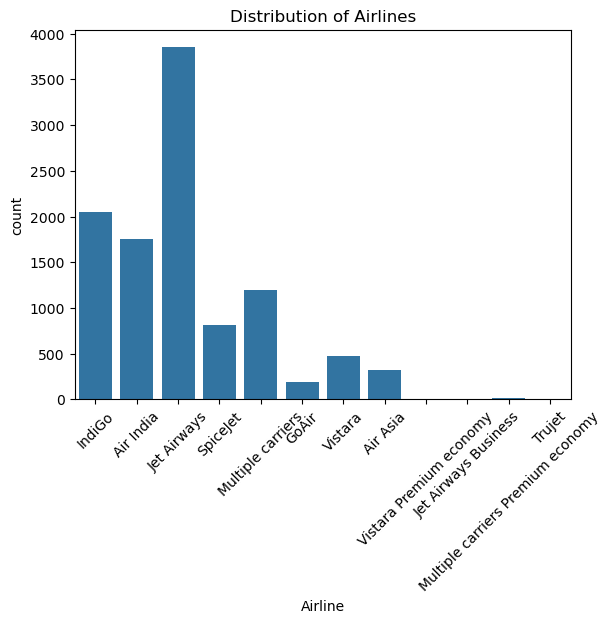

In [15]:
sns.countplot(x='Airline',data=df)

print(df.Airline.value_counts())

plt.title('Distribution of Airlines')
plt.xticks(rotation=45)
plt.show()

### Airline
> - Jet Airways appears most frequently.
> - Multiple Airlines and IndiGo also have high counts.
> - Trujet has very few observations.

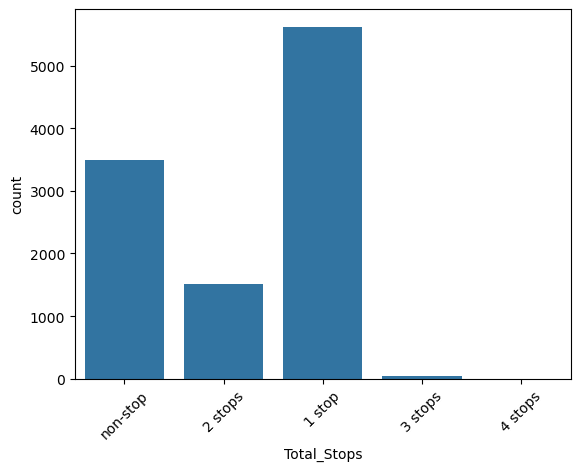

In [11]:
sns.countplot(x='Total_Stops',data=df)

plt.xticks(rotation=45)
plt.show()

### Total Stops
> - Most flights have one stop.
> - Non-stop flights are the second most common.
> - Flights with three or four stops are rare.

C:\Users\dhara\AppData\Local\Temp\ipykernel_11820\2912207630.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Source', data=df, ax=axes[0], palette='Set2')
C:\Users\dhara\AppData\Local\Temp\ipykernel_11820\2912207630.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Destination', data=df, ax=axes[1], palette='Set2')


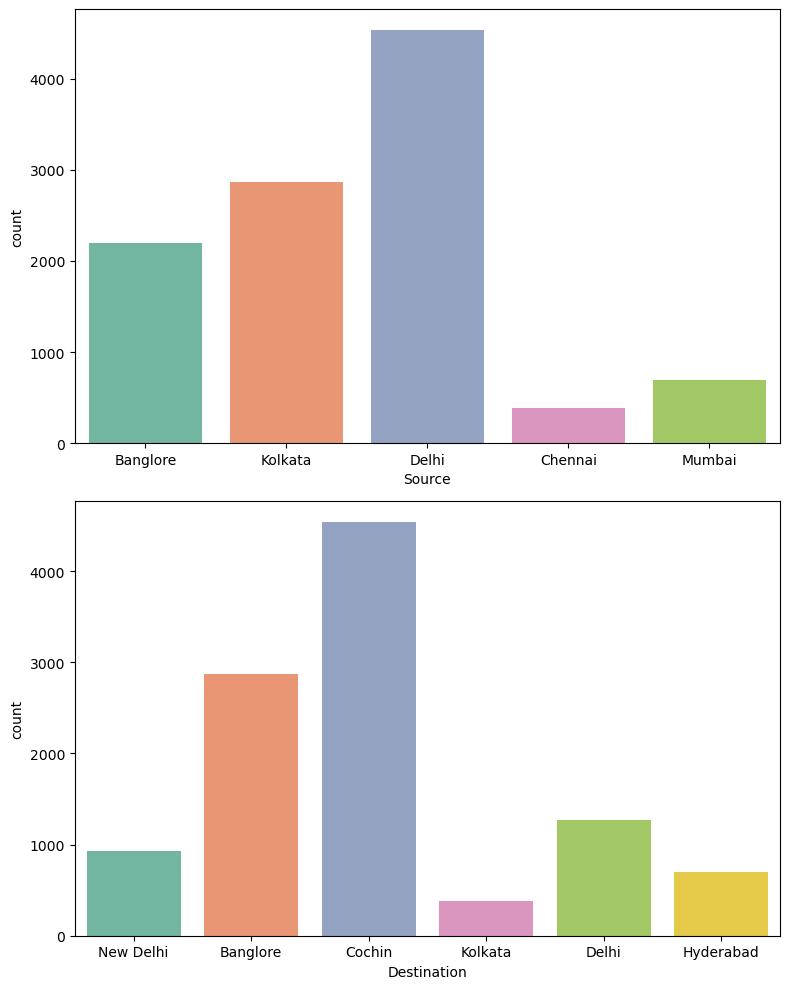

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

sns.countplot(x='Source', data=df, ax=axes[0], palette='Set2')
sns.countplot(x='Destination', data=df, ax=axes[1], palette='Set2')

plt.tight_layout()
plt.show()

### Source
> - Delhi is the most frequent departure city.
> - Kolkata is the second most common source.
> - Bangalore, Mumbai, and Chennai have comparatively fewer flights.

> The distribution is imbalanced.
 
### Destination
> - Cochin is the most common destination.
> - Bangalore, Delhi, New Delhi, and Hyderabad occur less frequently.
> - Destination frequencies are also imbalanced.